In [1]:
# Declare library
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, lit, broadcast, concat_ws
from pyspark.sql.types import FloatType, StringType
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.ml.feature import StringIndexer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
import gc
from tqdm.auto import tqdm
import xgboost as xgb
import seaborn as sns
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline
from xgboost.spark import SparkXGBClassifier
from pyspark.sql.types import NumericType
import warnings
import pickle
warnings.filterwarnings('ignore')

/Users/lamth/Documents/ieee-fraud-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_PATH = "/Users/lamth/Documents/ieee-fraud-detection"
train_transaction_path = os.path.join(DATA_PATH, "train_transaction.csv")
test_transaction_path = os.path.join(DATA_PATH, "test_transaction.csv")
train_identity_path = os.path.join(DATA_PATH, "train_identity.csv")
test_identity_path = os.path.join(DATA_PATH, "test_identity.csv")

In [3]:
cat_cols = [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'M4', 'M6',                          # giữ 2 M cols có signal cao nhất
    'id_30', 'id_31', 'DeviceType'        # device info có giá trị
]

identity_cols = [
    'TransactionID',
    'id_30', 'id_31', 'id_33', 'DeviceType', 'DeviceInfo'
]

core_cols = [
    'TransactionID', 'TransactionDT', 'TransactionAmt',
    'card1', 'card2', 'card3', 'card5',
    'addr1', 'addr2', 'dist1',
    # C columns — đếm số lần trùng giao dịch
    'C1', 'C2', 'C6', 'C11', 'C13', 'C14',
    # D columns — tối thiểu cần thiết
    'D1',   # bắt buộc để tạo UID
    'D10',  # time delta có correlation cao
    'D15',  # time delta có correlation cao
]

v_no_nan = [1,3,4,6,8,11]
v_no_nan += [13,14,17,20,23,26,27,30]
v_no_nan += [36,37,40,41,44,47,48]
v_no_nan += [54,56,59,62,65,67,68,70]
v_no_nan += [76,78,80,82,86,88,89,91]
v_no_nan += [107,108,111,115,117,120,121,123]
v_no_nan += [124,127,129,130,136]
v_no_nan += [281,283,289,296,301,314]
v_no_nan += [294,284,285,286,291,297]
v_no_nan += [303,305,307,309,310,320]

v_cols = ['V' + str(x) for x in sorted(set(v_no_nan))]

transaction_cols = core_cols + cat_cols + v_cols + ['isFraud']

transaction_cols_test = [c for c in transaction_cols if c != 'isFraud']

In [4]:
"""
ProductCD: Mã loại sản phẩm/dịch vụ trong giao dịch (W, H, C, S, R). Phần lớn giao dịch có giá trị "W", và 
mặc dù số giao dịch "W" nhiều hơn "C" rất nhiều, nhưng số giao dịch fraud của hai loại này gần tương đương 
— cho thấy ProductCD "C" có tỷ lệ fraud cao nhất. 

card4: Tương ứng với tên công ty thẻ Medium (visa, mastercard, discover, american express).

card6: Tương ứng với loại thẻ Medium (debit, credit, debit or credit, charge card).

P_emaildomain: Email domain của người mua . Email domain bất thường hoặc hiếm gặp thường liên quan đến fraud.

R_emaildomain — Email domain của người nhận. Phần lớn giao dịch không có giá trị R_emaildomain 
vì không phải giao dịch nào cũng cần gửi biên lai cho người nhận.

M4, M6: Các cột M là các cột "match" — ví dụ kiểm tra xem tên trên thẻ và địa chỉ có khớp nhau không. Giữ M4 và M6 vì qua 
EDA hai cột này có signal tương quan với fraud cao nhất trong nhóm M1–M9.

id_30: OS của thiết bị (Windows 10, iOS 12, Android 8...). Hệ điều hành lạ hoặc cũ bất thường là dấu hiệu đáng ngờ.

id_31: Trình duyệt và phiên bản (chrome 71.0, safari 12.0...) giúp phát hiện bot hoặc thiết bị giả mạo.

DeviceType: desktop hoặc mobile. Loại thiết bị ảnh hưởng đến.

DeviceInfo: Thông tin chi tiết về thiết bị (model máy, OS build...). 
Cột này không đưa vào cat_cols để frequency encode vì cardinality quá cao, 
nhưng vẫn giữ trong identity_cols để join.

TransactionDT: Timedelta tính từ một mốc thời gian tham chiếu, không phải timestamp thực, dùng để tạo tx_hour, tx_day_of_week 
và đặc biệt để tính D1_norm cho UID.

TransactionAmt: Số tiền giao dịch (USD). 

card1, card2, card3, card5: Thông tin thẻ thanh toán như loại thẻ, danh mục thẻ, ngân hàng phát hành, quốc gia. 
card1 đặc biệt quan trọng vì kết hợp card1 + D1 + addr1 giúp định danh từng client (tạo UID)


addr1, addr2: Địa chỉ billing region và billing country. Gần 99% giao dịch có cùng giá trị addr2
cho thấy đây là mã quốc gia và hầu hết giao dịch đến từ cùng một quốc gia

C1, C2, C6, C11, C13, C14: Các cột đếm, ví dụ số địa chỉ được liên kết với thẻ thanh toán.

Số ngày kể từ khi bắt đầu sử dụng thẻ tín dụng. Lấy TransactionDT trừ D1 sẽ cho ra một giá trị gần như cố định cho mỗi client — đây chính là cơ sở để tạo D1_norm trong UID.

D10, D15: Timedelta, ví dụ số ngày giữa các giao dịch trước đó
"""

'\nProductCD: Mã loại sản phẩm/dịch vụ trong giao dịch (W, H, C, S, R). Phần lớn giao dịch có giá trị "W", và \nmặc dù số giao dịch "W" nhiều hơn "C" rất nhiều, nhưng số giao dịch fraud của hai loại này gần tương đương \n— cho thấy ProductCD "C" có tỷ lệ fraud cao nhất. \n\ncard4: Tương ứng với tên công ty thẻ Medium (visa, mastercard, discover, american express).\n\ncard6: Tương ứng với loại thẻ Medium (debit, credit, debit or credit, charge card).\n\nP_emaildomain: Email domain của người mua . Email domain bất thường hoặc hiếm gặp thường liên quan đến fraud.\n\nR_emaildomain — Email domain của người nhận. Phần lớn giao dịch không có giá trị R_emaildomain \nvì không phải giao dịch nào cũng cần gửi biên lai cho người nhận.\n\nM4, M6: Các cột M là các cột "match" — ví dụ kiểm tra xem tên trên thẻ và địa chỉ có khớp nhau không. Giữ M4 và M6 vì qua \nEDA hai cột này có signal tương quan với fraud cao nhất trong nhóm M1–M9.\n\nid_30: OS của thiết bị (Windows 10, iOS 12, Android 8...). Hệ đ

# Load data by PySpark

In [4]:
warnings.filterwarnings('ignore')
spark = SparkSession.builder \
    .appName("IEEE_Fraud_Detection") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "6g") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.sql.shuffle.partitions", "400") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .getOrCreate()

# Giảm log noise
spark.sparkContext.setLogLevel("WARN")

print(f"Spark version: {spark.version}")
print("SparkSession khởi tạo thành công!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/21 15:50:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/21 15:50:04 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/21 15:50:04 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


Spark version: 4.1.1
SparkSession khởi tạo thành công!


In [5]:
train_tx_raw = spark.read.csv(
    train_transaction_path,
    header=True,
    inferSchema=True
)

available_tx_cols = [c for c in transaction_cols if c in train_tx_raw.columns]
train_tx = train_tx_raw.select(available_tx_cols)
train_id_raw = spark.read.csv(
    train_identity_path,
    header=True,
    inferSchema=True
)
available_id_cols = [c for c in identity_cols if c in train_id_raw.columns]
train_id = train_id_raw.select(available_id_cols)

test_tx_raw = spark.read.csv(
    test_transaction_path,
    header=True,
    inferSchema=True
)
available_test_cols = [c for c in transaction_cols_test if c in test_tx_raw.columns]
test_tx = test_tx_raw.select(available_test_cols)

test_id_raw = spark.read.csv(
    test_identity_path,
    header=True,
    inferSchema=True
)
test_id_raw = test_id_raw.select([
    F.col(f"`{old}`").alias(new)
    for old, new in zip(test_id_raw.columns, train_id_raw.columns)
])
available_test_id_cols = [c for c in identity_cols if c in test_id_raw.columns]
test_id = test_id_raw.select(available_test_id_cols)


In [6]:
train_df = train_tx.join(train_id, on='TransactionID', how='left').limit(10000)
test_df  = test_tx.join(test_id,  on='TransactionID', how='left').limit(10000)

train_df.cache()
test_df.cache()

print("Train shape:", (train_df.count(), len(train_df.columns)))
print("Test shape:", (test_df.count(), len(test_df.columns)))


26/03/21 15:50:28 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Train shape: (10000, 100)


Test shape: (10000, 99)


## EDA

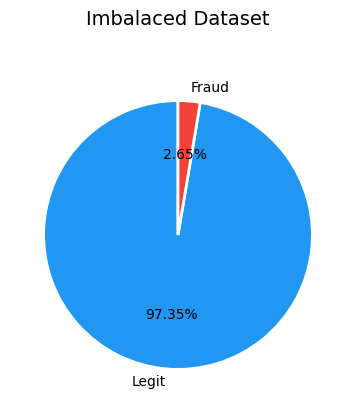


Fraud rate: 2.65%
scale_pos_weight for XGBoost: 36.7


In [9]:
# phân phối nhãn
label_dist = train_df.groupBy('isFraud').count().orderBy('isFraud').collect()
labels  = [f"{'Fraud' if r['isFraud'] else 'Legit'}" for r in label_dist]
counts  = [r['count'] for r in label_dist]
total   = sum(counts)
fig, axes = plt.subplots(figsize=(8, 4))

# Pie chart
axes.pie(counts, labels=labels, autopct='%1.2f%%',
            colors=['#2196F3', '#F44336'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.suptitle('Imbalaced Dataset', fontsize=14, y=1.02)
plt.savefig('./output_label_dist.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

fraud_rate = counts[1] / total * 100
scale_pos_weight_val = counts[0] / counts[1]
print(f"\nFraud rate: {fraud_rate:.2f}%")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight_val:.1f}")

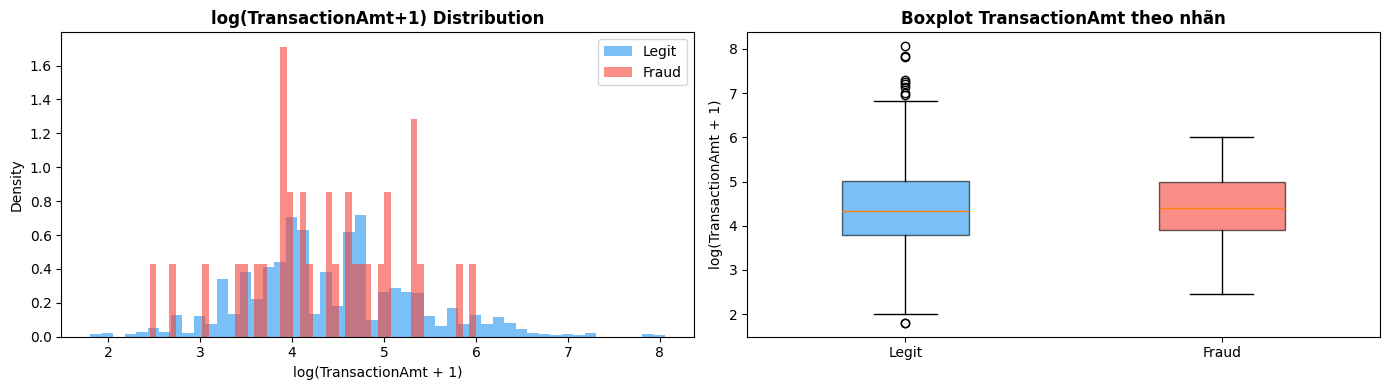

Sample size visualize: 1,083 rows (10% dataset)


In [10]:
sample_df = train_df.select('TransactionAmt', 'isFraud').sample(fraction=0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in [(0, '#2196F3', 'Legit'), (1, '#F44336', 'Fraud')]:
    subset = sample_df[sample_df['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset), bins=50, alpha=0.6, color=color, label=name, density=True)
    axes[1].boxplot(np.log1p(subset), positions=[label], widths=0.4,
                    patch_artist=True, boxprops=dict(facecolor=color, alpha=0.6))

axes[0].set_title('log(TransactionAmt+1) Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('Boxplot TransactionAmt theo nhãn', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legit', 'Fraud'])
axes[1].set_ylabel('log(TransactionAmt + 1)')

plt.tight_layout()
plt.savefig('./output_amt_dist.png', bbox_inches='tight')
plt.show()
print(f"Sample size visualize: {len(sample_df):,} rows (10% dataset)")

In [11]:
"""
Đối với phân phối log(TransactionAmt+1):
1. Legit có phân phối trải đều và mượt từ 2 đến 8 — khách hàng thật mua hàng với số tiền rất đa dạng, không cố định.
2 Fraud có đỉnh nhọn rõ ràng tại khoảng log ≈ 4 và log ≈ 5.3, kẻ gian thường thử giao dịch ở một số mức tiền quen thuộc thay vì mua ngẫu nhiên như người thật. 

Đối với Boxplot của lượng giao dịch:
1. Median của Legit và Fraud gần như bằng nhau nhìn vào số tiền trung bình thì không thể phân biệt được
2. Legit có outlier cao cho thấy giao dịch thật thường giao dịch lớn - tức mua hàng đắt
3. Fraud thể hiện giao dịch gian lận thường ổn định để tránh bị chú ý đến.
"""

'\nĐối với phân phối log(TransactionAmt+1):\n1. Legit có phân phối trải đều và mượt từ 2 đến 8 — khách hàng thật mua hàng với số tiền rất đa dạng, không cố định.\n2 Fraud có đỉnh nhọn rõ ràng tại khoảng log ≈ 4 và log ≈ 5.3, kẻ gian thường thử giao dịch ở một số mức tiền quen thuộc thay vì mua ngẫu nhiên như người thật. \n\nĐối với Boxplot của lượng giao dịch:\n1. Median của Legit và Fraud gần như bằng nhau nhìn vào số tiền trung bình thì không thể phân biệt được\n2. Legit có outlier cao cho thấy giao dịch thật thường giao dịch lớn - tức mua hàng đắt\n3. Fraud thể hiện giao dịch gian lận thường ổn định để tránh bị chú ý đến.\n'

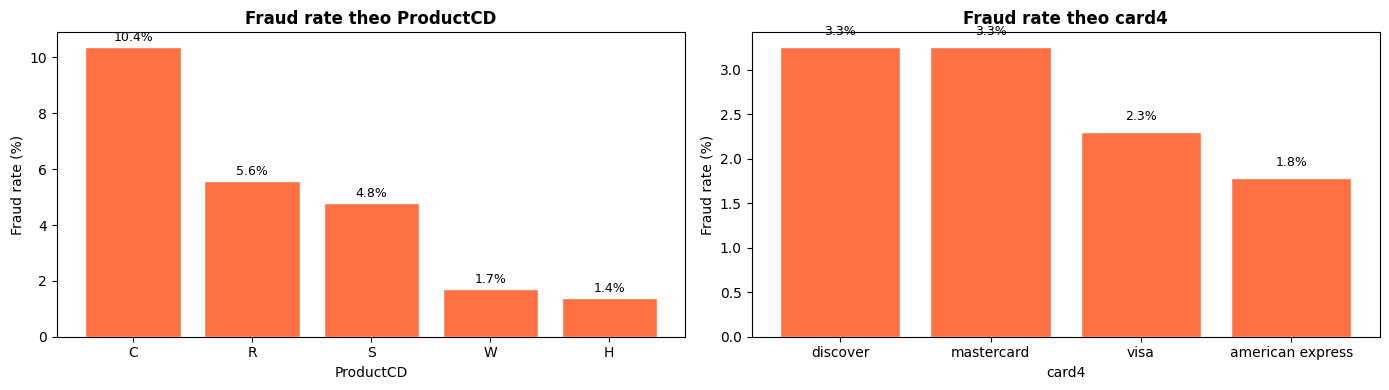

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['ProductCD', 'card4']):
    fraud_by_cat = (
        train_df.groupBy(col)
        .agg(
            F.count('isFraud').alias('total'),
            F.sum('isFraud').alias('fraud_count')
        )
        .withColumn('fraud_rate', F.round(F.col('fraud_count') / F.col('total') * 100, 2))
        .orderBy(F.col('fraud_rate').desc())
        .filter(F.col(col).isNotNull())
        .toPandas()
    )
    bars = ax.bar(fraud_by_cat[col].fillna('Unknown').astype(str),
                  fraud_by_cat['fraud_rate'],
                  color='#FF7043', edgecolor='white', linewidth=1)
    ax.set_title(f'Fraud rate theo {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fraud rate (%)')
    for bar, rate in zip(bars, fraud_by_cat['fraud_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('./output_fraud_by_cat.png', bbox_inches='tight')
plt.show()

## 5. Feature Engineering

Magic Feature: Tạo UID -> mỗi client có card1 + addr1 + ngày bắt đầu dùng thẻ cố định (D_norm) 

D1 = số ngày kể từ lần đầu dùng thẻ

D_norm = ngày tham chiếu cố định

In [7]:
def add_uid(df):
    """Tạo UID định danh client từ card1 + addr1 + D1_norm"""
    df = df.withColumn(
        'D1_norm',
        F.round(
            F.col('TransactionDT') / F.lit(86400) - F.col('D1'),
            scale=0
        )
    )
    df = df.withColumn(
        'uid',
        F.concat_ws('_',
            F.col('card1').cast('string'),
            F.col('addr1').cast('string'),
            F.col('D1_norm').cast('string')
        )
    )
    return df

train_df = add_uid(train_df)
test_df  = add_uid(test_df)

n_uid   = train_df.select('uid').distinct().count()
n_total = train_df.count()
print(f"Số UID unique   : {n_uid:,}")
print(f"Số giao dịch    : {n_total:,}")
print(f"Avg tx per user : {n_total/n_uid:.2f}")

Số UID unique   : 7,107
Số giao dịch    : 10,000
Avg tx per user : 1.41


## Aggregated features

In [8]:
# Tạo từ TRAIN rồi join vào cả train và test (tránh data leakage: chỉ dùng thống kê từ train)
print("Tính aggregated features theo UID ...")
uid_agg = (
    train_df
    .groupBy('uid')
    .agg(
        F.count('TransactionID').alias('uid_tx_count'),
        F.mean('TransactionAmt').alias('uid_amt_mean'),
        F.stddev('TransactionAmt').alias('uid_amt_std'),
        F.max('TransactionAmt').alias('uid_amt_max'),
        F.min('TransactionAmt').alias('uid_amt_min'),
        F.mean('D10').alias('uid_D10_mean'),
        F.mean('C1').alias('uid_C1_mean'),
    )
)

# Điền std = 0 khi chỉ có 1 giao dịch (tránh NaN)
uid_agg = uid_agg.fillna({'uid_amt_std': 0.0})

# Join vào train và test
train_df = train_df.join(uid_agg, on='uid', how='left')
test_df  = test_df.join(uid_agg,  on='uid', how='left')
train_df.cache()
test_df.cache()
uid_agg.show(5)

Tính aggregated features theo UID ...
+------------------+------------+------------+-----------------+-----------+-----------+------------+-----------+
|               uid|uid_tx_count|uid_amt_mean|      uid_amt_std|uid_amt_max|uid_amt_min|uid_D10_mean|uid_C1_mean|
+------------------+------------+------------+-----------------+-----------+-----------+------------+-----------+
| 13926_315.0_-13.0|           1|        68.5|              0.0|       68.5|       68.5|        13.0|        1.0|
|    2755_325.0_1.0|           1|        29.0|              0.0|       29.0|       29.0|         0.0|        1.0|
|    4663_330.0_1.0|           1|        59.0|              0.0|       59.0|       59.0|         0.0|        1.0|
|18132_476.0_-111.0|           7|        75.0|33.54101966249684|      120.0|       35.0|        85.0|        2.0|
|    4497_420.0_1.0|           1|        50.0|              0.0|       50.0|       50.0|        NULL|        1.0|
+------------------+------------+------------+----

## Frequency Encoding

In [9]:
# Thay thế StringIndexer — encode theo tần suất xuất hiện trong train
print("Frequency for categorical columns ...")
freq_maps = {}  # lưu lại để dùng cho test set

encode_cols = ['ProductCD', 'card4', 'card6',
               'P_emaildomain', 'R_emaildomain',
               'DeviceType', 'id_30', 'id_31',
               'M4', 'M6']

encode_cols = [c for c in encode_cols if c in train_df.columns]

for col_name in encode_cols:
    freq = (
        train_df.groupBy(col_name)
        .count()
        .withColumnRenamed('count', f'{col_name}_freq')
    )
    # freq_maps[col_name] = freq
    train_df = train_df.join(freq, on=col_name, how='left')
    test_df  = test_df.join(freq,  on=col_name, how='left')
    # Điền 0 cho category không xuất hiện trong train
    test_df = test_df.fillna({f'{col_name}_freq': 0})

Frequency for categorical columns ...


In [10]:
def add_extra_features(df):
    # Giờ trong ngày (TransactionDT tính bằng giây từ epoch)
    df = df.withColumn('tx_hour',
        ((F.col('TransactionDT') / 3600) % 24).cast('int'))

    # Ngày trong tuần
    df = df.withColumn('tx_day_of_week',
        ((F.col('TransactionDT') / 86400) % 7).cast('int'))

    # Log transform TransactionAmt — giảm skewness (cố gắng phân phối theo hình chuông)
    df = df.withColumn('log_TransactionAmt',
        F.log1p(F.col('TransactionAmt')))

    # Tỷ lệ amt so với trung bình của UID
    df = df.withColumn('amt_to_uid_mean_ratio',
        F.when(
            F.col('uid_amt_mean').isNotNull() & (F.col('uid_amt_mean') > 0),
            F.col('TransactionAmt') / F.col('uid_amt_mean')
        ).otherwise(F.lit(1.0)))

    return df

train_df = add_extra_features(train_df)
test_df  = add_extra_features(test_df)

## Chuẩn bị dữ liệu cho Training

In [17]:
# Loại bỏ các cột không phải feature
exclude_cols = {
    'TransactionID', 'isFraud', 'uid', 'D1_norm',
    # Loại cột categorical gốc (đã được freq-encode)
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'M4', 'M6', 'DeviceType', 'id_30', 'id_31', 'DeviceInfo', 'id_33'
}

# Tự động lấy tất cả cột numeric còn lại
feature_cols = [
    field.name for field in train_df.schema.fields
    if field.name not in exclude_cols
    and isinstance(field.dataType, NumericType)
]

print(f"Total features: {len(feature_cols)}")
print(f"Some features sample: {feature_cols[:10]} ...")

Total features: 107
Some features sample: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1'] ...


In [18]:
# ── Fill NaN trước khi assemble ───────────────────────────────────────────────
# XGBoost xử lý được NaN, nhưng VectorAssembler mặc định fail với NaN
# Dùng handleInvalid='keep' thay vì fillna toàn bộ

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features',
    handleInvalid='keep'
)

# Tạo tập train và validation (75/25 theo thời gian — không random shuffle)
# TransactionDT tăng dần → split theo thời gian là đúng nhất
max_dt = train_df.agg(F.max('TransactionDT')).collect()[0][0]
min_dt = train_df.agg(F.min('TransactionDT')).collect()[0][0]
split_dt = min_dt + int((max_dt - min_dt) * 0.75)

train_set = train_df.filter(F.col('TransactionDT') <= split_dt)
val_set   = train_df.filter(F.col('TransactionDT') >  split_dt)

print(f"TransactionDT range: [{min_dt}, {max_dt}]")
print(f"Train set          : {train_set.count():,} rows")
print(f"Validation set     : {val_set.count():,} rows")

TransactionDT range: [86400, 313121]
Train set          : 8,681 rows
Validation set     : 1,319 rows


In [19]:
print("Assembling features ...")
train_assembled = assembler.transform(train_set).select('TransactionID', 'features', 'isFraud')
val_assembled   = assembler.transform(val_set).select('TransactionID', 'features', 'isFraud')
test_assembled  = assembler.transform(test_df).select('TransactionID', 'features')

# Cache để tránh recompute khi train
train_assembled.cache()
val_assembled.cache()

print("Feature assembly hoàn tất!")
train_assembled.show(3)

Assembling features ...
Feature assembly hoàn tất!


+-------------+--------------------+-------+
|TransactionID|            features|isFraud|
+-------------+--------------------+-------+
|      2988962|[141079.0,72.95,1...|      0|
|      2988945|[140871.0,72.95,1...|      0|
|      2994258|[236956.0,10.0,10...|      0|
+-------------+--------------------+-------+
only showing top 3 rows


## Training với SparkXGBClassifier

In [20]:
n_legit = train_set.filter(F.col('isFraud') == 0).count()
n_fraud = train_set.filter(F.col('isFraud') == 1).count()
spw     = round(n_legit / n_fraud, 1)
print(f"scale_pos_weight = {n_legit:,} / {n_fraud:,} = {spw}")

class TrainingCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds, patience=50, save_path="best_xgb_model"):
        self.total_rounds  = total_rounds
        self.patience      = patience
        self.save_path     = save_path
        self.best_auc      = -float('inf')
        self.best_round    = 0
        self.no_improve    = 0
        self._pbar         = None
        self._stopped      = False

    def before_training(self, model):
        self.start_time = time.time()
        self._pbar = tqdm(
            total=self.total_rounds,
            desc="Training XGBoost",
            unit="round",
            bar_format="{l_bar}{bar:30}{r_bar}",
            colour="green",
            dynamic_ncols=True,
        )
        return model

    def after_iteration(self, model, epoch, evals_log):
        elapsed = time.time() - self.start_time
        avg_t   = elapsed / (epoch + 1)
        eta     = avg_t * (self.total_rounds - epoch - 1)

        keys      = list(evals_log.keys())
        train_auc = list(evals_log[keys[0]].values())[0][-1] if len(keys) >= 1 else None
        val_auc   = list(evals_log[keys[1]].values())[0][-1] if len(keys) >= 2 else None

        postfix = {"train-AUC": f"{train_auc:.4f}" if train_auc else "-"}
        if val_auc is not None:
            postfix["val-AUC"] = f"{val_auc:.4f}"
            postfix["best"]    = f"{self.best_auc:.4f}"
            postfix["patience"] = f"{self.no_improve}/{self.patience}"
        postfix["ETA"] = f"{eta:.0f}s"
        self._pbar.set_postfix(postfix)
        self._pbar.update(1)

        if val_auc is not None:
            if val_auc > self.best_auc + 1e-5: 
                self.best_auc   = val_auc
                self.best_round = epoch + 1
                self.no_improve = 0
                
                booster = model.save_raw()              
                os.makedirs(self.save_path, exist_ok=True)
                raw_path = os.path.join(self.save_path, "best_booster.ubj")
                with open(raw_path, "wb") as fp:
                    fp.write(booster)
            else:
                self.no_improve += 1
                if self.no_improve >= self.patience:
                    self._stopped = True
                    self._pbar.write(
                        f"\n Early stopping at the round {epoch+1} "
                        f"(Best val-AUC={self.best_auc:.4f} at the round{self.best_round})"
                    )
                    return True 

        return False

    def after_training(self, model):
        self._pbar.close()
        total = time.time() - self.start_time
        status = "Early stopped" if self._stopped else "Completed"
        print(f"\n{'='*55}")
        print(f"{status}! Total time: {total/60:.1f} minutes")
        print(f"Best val-AUC    : {self.best_auc:.4f}  (round {self.best_round})")
        print(f"The best model: {self.save_path}/best_booster.ubj")
        print(f"{'='*55}")
        return model

N_ESTIMATORS  = 500
PATIENCE      = 50
SAVE_PATH     = "./best_xgb_model"

progress_cb = TrainingCallback(
    total_rounds=N_ESTIMATORS,
    patience=PATIENCE,
    save_path=SAVE_PATH,
)

xgb_model = SparkXGBClassifier(
    features_col='features',
    label_col='isFraud',
    prediction_col='prediction',
    probability_col='probability',

    # Hyperparameters
    n_estimators=N_ESTIMATORS,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=100,
    scale_pos_weight=spw,

    # Tối ưu bộ nhớ
    tree_method='hist',
    max_bin=256,

    # Phân tán
    num_workers=2,
    use_gpu=False,

    # Metric + early stopping built-in (backup)
    eval_metric='auc',
    early_stopping_rounds=PATIENCE,
    validation_indicator_col='isVal',
    callbacks=[progress_cb],
)

scale_pos_weight = 8,458 / 223 = 37.9


In [21]:
# Chuẩn bị dữ liệu train + validation cho early stopping
# SparkXGBClassifier cần 1 DataFrame duy nhất với cột isVal để phân biệt
train_with_val = (
    train_assembled.withColumn('isVal', F.lit(False))
    .union(
        val_assembled.withColumn('isVal', F.lit(True))
    )
)

# Training
print("Start training ...")
t0 = time.time()

xgb_fitted = xgb_model.fit(train_with_val)

SPARK_MODEL_PATH = "./best_spark_xgb_model"
xgb_fitted.write().overwrite().save(SPARK_MODEL_PATH)

elapsed = time.time() - t0
print(f"\nTraining completed in {elapsed/60:.1f} minutes")

Start training ...


2026-03-21 15:29:48,899 INFO XGBoost-PySpark: _fit Running xgboost-3.2.0 on 2 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'eval_metric': 'auc', 'learning_rate': 0.05, 'max_bin': 256, 'max_depth': 6, 'min_child_weight': 100, 'scale_pos_weight': 37.9, 'subsample': 0.8, 'tree_method': 'hist', 'use_gpu': False, 'nthread': 1}
	train_call_kwargs_params: {'callbacks': [<__main__.TrainingCallback object at 0x12ab9f3e0>], 'early_stopping_rounds': 50, 'verbose_eval': True, 'num_boost_round': 500}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-21 15:32:49,785 INFO XGBoost-PySpark: _train_booster Training on CPUs 2]
[15:32:50] Task 1 got rank 1
[15:32:50] Task 0 got rank 0
Training XGBoost:   0%|                              | 0/500 [00:00<?, ?round/s]/Users/lamth/Documents/ieee-fraud-detection/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [15:32:51] WARNING: /Users/runner/work/xgboost/xgboost/src/lear


Training completed in 9.2 minutes


In [22]:
val_pred = xgb_fitted.transform(val_assembled)

# AUC-ROC
auc_evaluator = BinaryClassificationEvaluator(
    labelCol='isFraud',
    rawPredictionCol='probability',
    metricName='areaUnderROC'
)
auc_roc = auc_evaluator.evaluate(val_pred)

# AUC-PR
auc_pr_evaluator = BinaryClassificationEvaluator(
    labelCol='isFraud',
    rawPredictionCol='probability',
    metricName='areaUnderPR'
)
auc_pr = auc_pr_evaluator.evaluate(val_pred)

# Accuracy, Precision, Recall, F1
mc_eval = MulticlassClassificationEvaluator(
    labelCol='isFraud', predictionCol='prediction'
)

accuracy  = mc_eval.setMetricName('accuracy').evaluate(val_pred)
precision = mc_eval.setMetricName('weightedPrecision').evaluate(val_pred)
recall    = mc_eval.setMetricName('weightedRecall').evaluate(val_pred)
f1        = mc_eval.setMetricName('f1').evaluate(val_pred)

print("="*45)
print("  MODEL EVALUATION RESULTS")
print("="*45)
print(f"  AUC-ROC   : {auc_roc:.4f} ")
print(f"  AUC-PR    : {auc_pr:.4f} ")
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("="*45)

/Users/lamth/.local/share/uv/python/cpython-3.12.11-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py:279: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
/Users/lamth/.local/share/uv/python/cpython-3.12.11-macos-aarch64-none/lib/python3.12/multiprocessing/resource_tracker.py:279: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown
  warnings.warn('resource_tracker: There appear to be %d '
2026-03-21 15:36:30,421 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-21 15:37:53,439 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-21 15:39:50,984 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-21 15:41:10,967 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs
2026-03-21 15:41:27,265 INFO XGBoost-PySpark: predict_udf Do the inference on 

  MODEL EVALUATION RESULTS
  AUC-ROC   : 0.8905 
  AUC-PR    : 0.4563 
  Accuracy  : 0.8628
  Precision : 0.9626
  Recall    : 0.8628
  F1 Score  : 0.9030


2026-03-21 15:41:48,938 INFO XGBoost-PySpark: predict_udf Do the inference on the CPUs


In [11]:
ARTIFACTS_DIR = "./artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

In [24]:
print("Exporting uid_agg ...")
uid_agg_export = (
    train_df
    .groupBy('uid')
    .agg(
        F.count('TransactionID').alias('uid_tx_count'),
        F.mean('TransactionAmt').alias('uid_amt_mean'),
        F.stddev('TransactionAmt').alias('uid_amt_std'),
        F.max('TransactionAmt').alias('uid_amt_max'),
        F.min('TransactionAmt').alias('uid_amt_min'),
        F.mean('D10').alias('uid_D10_mean'),
        F.mean('C1').alias('uid_C1_mean'),
    )
    .fillna({'uid_amt_std': 0.0})
    .toPandas()
)
uid_agg_export.to_parquet(f"{ARTIFACTS_DIR}/uid_agg.parquet", index=False)
print(f" uid_agg saved → {ARTIFACTS_DIR}/uid_agg.parquet")

Exporting uid_agg ...
 uid_agg saved → ./artifacts/uid_agg.parquet


In [12]:
print("Exporting freq_maps ...")
ENCODE_COLS = [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'DeviceType', 'id_30', 'id_31', 'M4', 'M6',
]
freq_maps_export = {}
all_cols = [f.name for f in train_df.schema.fields]
for col_name in ENCODE_COLS:
    if col_name not in all_cols:
        continue
    freq_df = (
        train_df.groupBy(col_name)
        .count()
        .withColumnRenamed('count', f'{col_name}_freq')
        .toPandas()
    )
    freq_maps_export[col_name] = freq_df
    print(f"  {col_name}: {len(freq_df)} categories")

with open(f"{ARTIFACTS_DIR}/freq_maps.pkl", "wb") as f:
    pickle.dump(freq_maps_export, f)
print(f" freq_maps saved → {ARTIFACTS_DIR}/freq_maps.pkl")



Exporting freq_maps ...


  ProductCD: 5 categories
  card4: 5 categories
  card6: 3 categories
  P_emaildomain: 51 categories
  R_emaildomain: 40 categories
  DeviceType: 3 categories
  id_30: 54 categories
  id_31: 52 categories
  M4: 4 categories
  M6: 3 categories
 freq_maps saved → ./artifacts/freq_maps.pkl


In [13]:
MODEL_PATH = "./best_xgb_model/best_booster.ubj"
print(f"\n Model: {MODEL_PATH}")
print("\nDone! Use command on terminal: streamlit run app.py")


 Model: ./best_xgb_model/best_booster.ubj

Done! Use command on terminal: streamlit run app.py
